In [1]:
import pandas as pd
penguins = pd.read_csv('https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/penguins.csv').dropna()
penguins.shape

(333, 9)

In [2]:
from sklearn.model_selection import train_test_split

# Separate predictor variables from class label
X = penguins.drop(['species','rowid'], axis=1)
y = penguins.species.astype("category").cat.codes

# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(
                        X, y, test_size=.3, random_state=42)
X_train

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
27,Biscoe,40.5,17.9,187.0,3200.0,female,2007
295,Dream,49.2,18.2,195.0,4400.0,male,2007
305,Dream,52.8,20.0,205.0,4550.0,male,2008
62,Biscoe,37.6,17.0,185.0,3600.0,female,2008
182,Biscoe,47.3,15.3,222.0,5250.0,male,2007
...,...,...,...,...,...,...,...
195,Biscoe,49.6,15.0,216.0,4750.0,male,2008
77,Torgersen,37.2,19.4,184.0,3900.0,male,2008
112,Biscoe,39.7,17.7,193.0,3200.0,female,2009
281,Dream,45.2,17.8,198.0,3950.0,female,2007


Dado que tenemos dos atributos de datos categóricos llamados *isla* y *sexo*, sin ningún orden de categorías que pueda inducirse, solo tenemos dos opciones: descartar el atributo (haremos esto para el atributo *sexo*) o aplicar una transformación **OneHotEncoder**:

In [3]:
from sklearn.preprocessing import OneHotEncoder

# Initialize the OneHotEncoder
encoder = OneHotEncoder()

# Transform the island attribute into several boolean numerical attributes
encoder.fit(X_train[["island"]])
X_train_encoded = encoder.transform(X_train[["island"]]).toarray()

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(X_train[["island"]].columns))

X_train_encoded_df.head()

,island_Biscoe,island_Dream,island_Torgersen
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


Una vez aplicada la transformación del atributo *isla* en tres atributos binarios equivalentes, vamos a fusionarlos con el resto de los datos, descartando también los atributos categóricos originales porque ya no los necesitamos.

In [4]:
X_train_num = X_train.drop(["island", "sex"], axis=1)
X_train_num.reset_index(drop=True, inplace=True)

X_train_encoded_df.reset_index(drop=True, inplace=True)

X_train_prepared = pd.concat([X_train_num, X_train_encoded_df], axis=1)

X_train_prepared

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,island_Biscoe,island_Dream,island_Torgersen
0,40.5,17.9,187.0,3200.0,2007,1.0,0.0,0.0
1,49.2,18.2,195.0,4400.0,2007,0.0,1.0,0.0
2,52.8,20.0,205.0,4550.0,2008,0.0,1.0,0.0
3,37.6,17.0,185.0,3600.0,2008,1.0,0.0,0.0
4,47.3,15.3,222.0,5250.0,2007,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
228,49.6,15.0,216.0,4750.0,2008,1.0,0.0,0.0
229,37.2,19.4,184.0,3900.0,2008,0.0,0.0,1.0
230,39.7,17.7,193.0,3200.0,2009,1.0,0.0,0.0
231,45.2,17.8,198.0,3950.0,2007,0.0,1.0,0.0


**Entrenamiento del árbol de decisión para clasificación**

In [5]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, criterion="entropy")
tree.fit(X_train_prepared, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

**Visualización del árbol (código auxiliar, no necesario aprenderlo)**

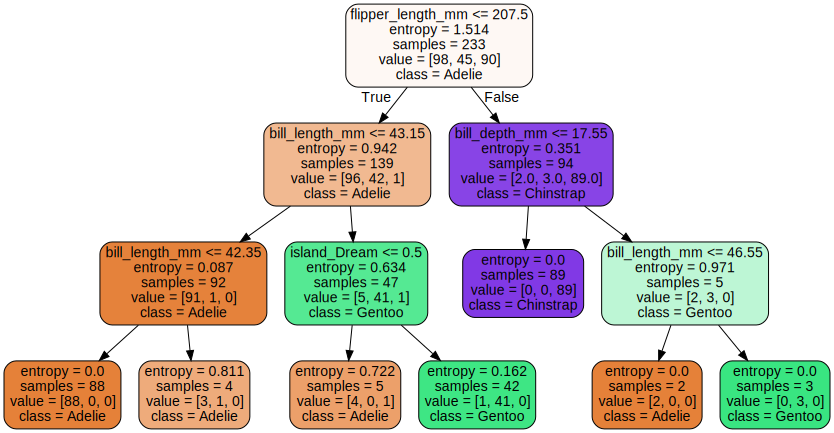

In [6]:
from sklearn.tree import export_graphviz
from graphviz import Source

import os
PROJECT_ROOT_DIR = "."
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "tree images")
os.makedirs(IMAGES_PATH, exist_ok=True)

# Get the actual class names from the original DataFrame
class_names = penguins['species'].unique().tolist()

export_graphviz(
    tree, # Our model learnt
    out_file = os.path.join(IMAGES_PATH, "penguins_tree_01.dot"),
    feature_names = X_train_prepared.columns,
    class_names = class_names,
    rounded = True,
    filled = True
)
Source.from_file(os.path.join(IMAGES_PATH, "penguins_tree_01.dot"))

Para realizar predicciones en el **conjunto de datos de test**, debemos recordar aplicar exactamente las mismas transformaciones que aplicamos a los datos de entrenamiento.

Para el **conjunto de test**, utilizamos el mismo *OneHotEncoder* definido previamente para los datos de entrenamiento y llamamos directamente a su método *transform()*: no es necesario volver a llamar al método *fit()*, ya que la transformación de atributos debe seguir la misma lógica aprendida cuando se procesaron los datos de entrenamiento.

In [7]:
X_test_encoded = encoder.transform(X_test[["island"]]).toarray()

X_test_encoded_df = pd.DataFrame(X_test_encoded,
                                 columns=encoder.get_feature_names_out(X_test[["island"]].columns))

X_test_num = X_test.drop(["island","sex"], axis=1)

X_test_num.reset_index(drop=True, inplace=True)
X_test_encoded_df.reset_index(drop=True, inplace=True)

X_test_prepared = pd.concat([X_test_num,X_test_encoded_df], axis=1)
X_test_prepared

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,island_Biscoe,island_Dream,island_Torgersen
0,39.5,16.7,178.0,3250.0,2007,0.0,1.0,0.0
1,50.9,17.9,196.0,3675.0,2009,0.0,1.0,0.0
2,42.1,19.1,195.0,4000.0,2008,0.0,0.0,1.0
3,46.6,14.2,210.0,4850.0,2008,1.0,0.0,0.0
4,41.1,18.2,192.0,4050.0,2008,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
95,37.8,18.3,174.0,3400.0,2007,1.0,0.0,0.0
96,39.2,19.6,195.0,4675.0,2007,0.0,0.0,1.0
97,45.8,14.2,219.0,4700.0,2008,1.0,0.0,0.0
98,43.2,18.5,192.0,4100.0,2008,0.0,1.0,0.0


In [8]:
test_predictions = tree.predict(X_test_prepared)
test_predictions

array([0, 1, 0, 2, 0, 1, 1, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0, 0,
       1, 2, 0, 0, 2, 1, 2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2,
       0, 0, 1, 0, 0, 1, 0, 2, 2, 0, 0, 2, 0, 0, 2, 2, 0, 1, 1, 0, 0, 1,
       0, 2, 0, 0, 0, 0, 2, 1, 2, 0, 0, 0, 0, 2, 0, 0, 2, 0, 1, 2, 0, 1,
       2, 2, 2, 1, 0, 0, 0, 0, 0, 2, 1, 0], dtype=int8)

In [9]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, test_predictions)

0.95

In [10]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, test_predictions)

array([[47,  1,  0],
       [ 3, 20,  0],
       [ 1,  0, 28]])

In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test, test_predictions))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95        48
           1       0.95      0.87      0.91        23
           2       1.00      0.97      0.98        29

    accuracy                           0.95       100
   macro avg       0.96      0.94      0.95       100
weighted avg       0.95      0.95      0.95       100



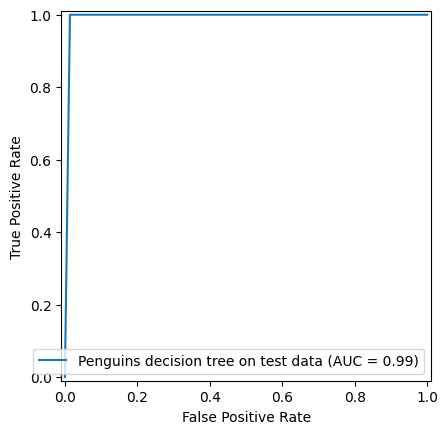

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(test_predictions, y_test, pos_label=2)
roc_auc = auc(fpr, tpr)

display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='Penguins decision tree on test data')
display.plot()
plt.show()